# Titanic Survival Prediction

**Installation**:  You will need to install python and jupyter.  The easiest way is to install the package `Anaconda` as follows. 

- Download Anaconda from [this link](https://www.anaconda.com/download)
- Install Anaconda from the downloaded file
- Open Jupyter Lab by 

    - (1) Click to the Start Windows Logo and Type in Anconda Promp.  Open Anaconda Promp
    - (2) In Anaconda Promp, type in: `jupyter lab` and hit Enter
 
 
 
- Install the `graphviz` package
    - Open Anaconda Prompt. 
    - Type in: `conda install python-graphviz`

**Data**: The data should be in the same folder as the notebook.


# 1. Data Preprocessing

#### Import

In [4]:
# import some packages
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn import metrics

In [5]:
# Import the data
df = pd.read_csv('titanic.csv')

In [6]:
# Check the variables
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

#### Assign the input and output variable

In [7]:
# Assign input variables
X = df.loc[:,['Pclass','Sex','Age','Fare','Embarked','SibSp','Parch']]

# Assign target variable
y = df['Survived']

#### Check and fix variable types

In [8]:
X.dtypes

Pclass        int64
Sex          object
Age         float64
Fare        float64
Embarked     object
SibSp         int64
Parch         int64
dtype: object

In [9]:
# Change Pclass to categorical variable
X['Pclass'] = X['Pclass'].astype(object)

#### Check and handle missing values

In [10]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
# Replace missing values by the median
X["Age"] = X["Age"].fillna(X["Age"].median())

# Impute the Embarked variable
X["Embarked"] = X["Embarked"].fillna("S")

#### Encode Categorical Variables

`sklearn` does not work directly with categorical variables. It requires the categorical variables to be encoded into numeric variables. There are multiple way to encode categorical variables.  Here, we implement the simplest way of encoding: `one-hot` encoding or `dummy` encoding. 

In [12]:
# Encode categorical variable
X = pd.get_dummies(X)

# 2. Split the data into training and testing

In [13]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.15)

# Train a model

## Decision Tree

In [14]:
from sklearn.tree import DecisionTreeClassifier

# Create a decision tree and train
tree1 = DecisionTreeClassifier(criterion='gini', max_leaf_nodes=3)
tree1.fit(x_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=3)

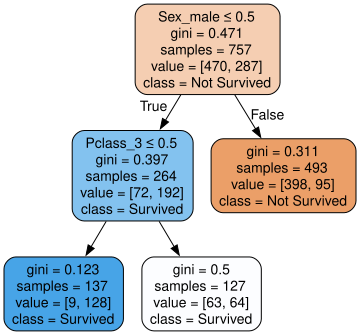

In [15]:
from sklearn import tree

import graphviz 

dot_data = tree.export_graphviz(tree1, out_file=None) 
dot_data = tree.export_graphviz(tree1, out_file=None, 
                     feature_names=x_train.columns,  
                     class_names=['Not Survived','Survived'],  
                     filled=True, rounded=True,  
                     special_characters=True)  

graph = graphviz.Source(dot_data)  

graph

## Test the model

In [16]:
# Prediction and accuracy on testing data

print('Testing Accuracy is:')
tree1.score(x_test, y_test)

Testing Accuracy is:


0.8283582089552238